# EPR Benchmark — Entropy Production Rate

Pour une séquence générée $\mathcal{T}_q = \{t_1, ..., t_{L_q}\}$ en réponse à une requête $q$, avec accès aux top-$K$ log-probabilités par token :

$$\text{EPR}_K(q) = \frac{1}{L_q} \sum_{j=1}^{L_q} \tilde{H}_K(q, t_{<j}) = -\frac{1}{L_q} \sum_{j=1}^{L_q} \sum_{k=1}^{K} p_{r(k),j} \log_2(p_{r(k),j})$$

où $p_{r(k),j}$ est la probabilité du $k$-ème token le plus probable à l'étape $j$.

**EPR faible** → modèle confiant → réponse probablement correcte  
**EPR élevé** → modèle hésite → risque d'hallucination

## Structure
1. Installation & Imports  
2. Authentification HuggingFace  
3. Téléchargement des datasets (WebQuestions, IMDb)  
4. Chargement du modèle  
5. Fonctions de processing LLM (génération + extraction top-K logprobs)  
6. Calcul de l'EPR  
7. Affichage des résultats


## 0. Installation & Imports

In [1]:
!pip install -q transformers torch datasets huggingface_hub scikit-learn matplotlib seaborn tqdm

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import json
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login, whoami
from datasets import load_dataset
from sklearn.metrics import roc_auc_score, average_precision_score

print(f"PyTorch          : {torch.__version__}")
print(f"CUDA disponible  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


## 1. Authentification HuggingFace

In [ ]:
HF_TOKEN = ""

login(token=HF_TOKEN)
print("Connecté en tant que :", whoami()["name"])


## 2. Configuration globale

In [ ]:
model_google    = "google/gemma-3-1b-it"
model_microsoft = "microsoft/phi-1_5"
model_tii       = "tiiuae/Falcon3-7B-Instruct"
# model_tii     = "tiiuae/Falcon3-10B-Instruct"
model_qwen      = "Qwen/Qwen2.5-0.5B-Instruct"
# model_qwen    = "Qwen/Qwen2.5-3B-Instruct"

ALL_MODELS = {
    "Gemma-3-1B"   : model_google,
    "Phi-1.5"      : model_microsoft,
    "Falcon3-7B"   : model_tii,
    "Qwen2.5-0.5B" : model_qwen,
}

K_LOGPROBS     = 15      # top-K log-probs exposés (papier : K <= 15 ou 20)
T_SAMPLE       = 1.0     # température de sampling
MAX_NEW_TOKENS = 50      # longueur max de la réponse générée
N_SAMPLES      = 1000    # questions par dataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device           : {DEVICE}")
print(f"K logprobs       : {K_LOGPROBS}  (top-K accessibles, comme une API black-box)")
print(f"Température      : {T_SAMPLE}   (non-greedy, papier §3.2)")
print(f"Échantillons     : {N_SAMPLES} par dataset")
print()
print("Modèles configurés :")
for name, path in ALL_MODELS.items():
    print(f"  • {name:20s} → {path}")


## 3. Téléchargement des Datasets

### 3.1 WebQuestions


In [ ]:
print("Chargement de WebQuestions...")
wq_raw = load_dataset("web_questions", split="train")

wq_data = []
for ex in wq_raw:
    q = ex["question"].strip()
    answers = ex["answers"]
    if answers:
        wq_data.append({
            "question"    : q,
            "ground_truth": answers[0],
            "all_answers" : answers,
        })

wq_df = (pd.DataFrame(wq_data)
           .sample(n=min(N_SAMPLES, len(wq_data)), random_state=42)
           .reset_index(drop=True))

print(f"WebQuestions : {len(wq_df)} exemples")
wq_df[["question", "ground_truth"]].head(3)

### 3.2 IMDb


In [ ]:
print("Chargement de IMDb...")
imdb_raw = load_dataset("imdb", split="test")

LABEL_MAP = {0: "negative", 1: "positive"}

imdb_data = []
for ex in imdb_raw:
    review       = ex["text"][:600].strip()
    ground_truth = LABEL_MAP[ex["label"]]
    question = (
        "Read the following movie review and answer with only one word: "
        "'positive' or 'negative'.\n\n"
        f"Review: {review}\n\nSentiment:"
    )
    imdb_data.append({"question": question, "ground_truth": ground_truth})

imdb_df = (pd.DataFrame(imdb_data)
             .sample(n=min(N_SAMPLES, len(imdb_data)), random_state=42)
             .reset_index(drop=True))

print(f"IMDb          : {len(imdb_df)} exemples")
print(imdb_df["ground_truth"].value_counts().to_string())

---
## 4. Chargement du Modèle


In [7]:
#  Sélection du modèle
ACTIVE_MODEL_KEY = "Qwen2.5-0.5B"   # Gemma-3-1B | Phi-1.5 | Falcon3-7B | Qwen2.5-0.5B
MODEL_NAME = ALL_MODELS[ACTIVE_MODEL_KEY]

print(f"Chargement : {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

active_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
active_model.eval()

print(f"Modèle chargé")
print(f"  Paramètres : {active_model.num_parameters() / 1e9:.2f}B")
print(f"  Device     : {next(active_model.parameters()).device}")

Chargement : Qwen/Qwen2.5-0.5B-Instruct


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modèle chargé
  Paramètres : 0.49B
  Device     : cuda:0



## 5. Fonctions de Processing LLM

Pipeline conforme au papier :
1. Générer la réponse (température = 1.0)
2. Extraire les **top-K log-probabilités** à chaque position de token
3. Calculer l'entropie estimée par token $\tilde{H}_K$
4. Moyenner sur toute la séquence → **EPR**

In [8]:
def generate_with_topk_logprobs(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = MAX_NEW_TOKENS,
    temperature: float  = T_SAMPLE,
    K: int              = K_LOGPROBS,
) -> dict:

    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,  # T_samp = 1.0
            top_p=1.0,
            return_dict_in_generate=True,
            output_scores=True,
        )

    # Tokens générés
    generated_ids  = outputs.sequences[0, inputs["input_ids"].shape[1]:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    token_texts    = [tokenizer.decode([tid]) for tid in generated_ids]

    # Extraction top-K log-probabilités à chaque étape j
    token_logprobs = []
    for step_scores in outputs.scores:
        log_probs_full = torch.log_softmax(step_scores[0], dim=-1)  # (vocab_size,)
        topk_lp, _    = torch.topk(log_probs_full, k=K)
        token_logprobs.append(topk_lp.cpu().tolist())

    return {
        "generated_text": generated_text,
        "token_logprobs" : token_logprobs,
        "token_texts"    : token_texts,
    }


def token_entropy_from_logprobs(logprobs_topk: list) -> float:
    """
    Calcule l'entropie estimée H̃_K pour UN token à partir de ses top-K log-probs.
    """
    probs = np.exp(np.array(logprobs_topk, dtype=np.float64))
    probs = np.clip(probs, 1e-12, 1.0)
    return float(-np.sum(probs * np.log2(probs)))


def compute_epr(token_logprobs: list) -> dict:
    """
    Calcule l'EPR_K(q) pour une séquence complète.

    """
    if not token_logprobs:
        return {"epr": float("nan"), "per_token_entropies": []}

    per_token = [token_entropy_from_logprobs(lp) for lp in token_logprobs]
    epr = float(np.mean(per_token))
    return {"epr": epr, "per_token_entropies": per_token}


def is_correct(generated: str, ground_truth, all_answers=None) -> bool:

    gen  = generated.strip().lower().split("\n")[0]
    refs = [str(ground_truth).strip().lower()]
    if all_answers:
        refs += [str(a).strip().lower() for a in all_answers]
    return any(ref in gen or gen in ref for ref in refs)



## 6. Calcul de l'EPR

Pour chaque question :
1. Le modèle génère une réponse libre
2. On extrait les top-K logprobs à chaque token
3. On calcule l'EPR de la séquence
4. On annote correct / hallucination


In [10]:
def run_epr_benchmark(
    model,
    tokenizer,
    df: pd.DataFrame,
    dataset_name: str,
    question_col: str = "question",
    gt_col: str       = "ground_truth",
    all_ans_col: str  = None,
) -> dict:
    """
    Pipeline EPR complète sur un DataFrame :
      1. Génération avec top-K logprobs
      2. Calcul de l'EPR_K par séquence (Éq. 10)
      3. Annotation correcte / hallucination
      4. Métriques : ROC-AUC, PR-AUC (EPR faible = confiant = score positif)
    """
    records = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"EPR [{dataset_name}]"):
        question     = row[question_col]
        ground_truth = row[gt_col]
        all_ans      = row.get(all_ans_col) if all_ans_col and all_ans_col in df.columns else None

        try:
            gen = generate_with_topk_logprobs(model, tokenizer, question)
            epr = compute_epr(gen["token_logprobs"])
            ok  = is_correct(gen["generated_text"], ground_truth, all_ans)

            records.append({
                "question"           : question,
                "generated"          : gen["generated_text"],
                "ground_truth"       : ground_truth,
                "correct"            : ok,
                "epr"                : epr["epr"],
                "seq_length"         : len(gen["token_logprobs"]),
                "per_token_entropies": epr["per_token_entropies"],
            })
        except Exception as e:
            print(f"  [Erreur idx={idx}] {e}")

    res = pd.DataFrame(records).dropna(subset=["epr"])

    eprs   = res["epr"].values
    labels = res["correct"].astype(int).values   # 1 = correct, 0 = hallucination
    try:
        roc_auc = roc_auc_score(labels, -eprs)
        pr_auc  = average_precision_score(labels, -eprs)
    except Exception:
        roc_auc = pr_auc = float("nan")

    accuracy       = float(res["correct"].mean())
    epr_true_mean  = float(res.loc[res["correct"],  "epr"].mean()) if res["correct"].any()  else float("nan")
    epr_false_mean = float(res.loc[~res["correct"], "epr"].mean()) if (~res["correct"]).any() else float("nan")

    summary = {
        "dataset"              : dataset_name,
        "model"                : ACTIVE_MODEL_KEY,
        "K"                    : K_LOGPROBS,
        "n_samples"            : len(res),
        "accuracy"             : round(accuracy, 4),
        "ROC_AUC"              : round(roc_auc, 4),
        "PR_AUC"               : round(pr_auc, 4),
        "EPR_mean_correct"     : round(epr_true_mean,  4),
        "EPR_mean_hallucinated": round(epr_false_mean, 4),
        "EPR_mean_global"      : round(float(res["epr"].mean()), 4),
        "results_df"           : res,
    }

    print(f"\n{'='*58}")
    print(f"  Dataset          : {dataset_name}")
    print(f"  Modèle           : {ACTIVE_MODEL_KEY}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  ROC-AUC          : {roc_auc:.4f}")
    print(f"  PR-AUC           : {pr_auc:.4f}")
    print(f"  EPR moyen (✓)    : {epr_true_mean:.4f}  ")
    print(f"  EPR moyen (✗)    : {epr_false_mean:.4f}")
    print(f"{'='*58}")

    return summary


### 6.1 Exécution sur WebQuestions

In [ ]:
summary_wq = run_epr_benchmark(
    model        = active_model,
    tokenizer    = tokenizer,
    df           = wq_df,
    dataset_name = "WebQuestions",
    question_col = "question",
    gt_col       = "ground_truth",
    all_ans_col  = "all_answers",
)

### 6.2 Exécution sur IMDb

In [ ]:
summary_imdb = run_epr_benchmark(
    model        = active_model,
    tokenizer    = tokenizer,
    df           = imdb_df,
    dataset_name = "IMDb",
    question_col = "question",
    gt_col       = "ground_truth",
)

### 6.3 Libération mémoire GPU (avant de changer de modèle)

In [ ]:
del active_model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Mémoire GPU libérée — changez ACTIVE_MODEL_KEY et relancez §4")


## 7. Affichage des Résultats

In [ ]:
# ── Agrégation ───────────────────────────────────────────────────────────────
ALL_SUMMARIES = [
    summary_wq,
    summary_imdb,
    # Résultats d'autres modèles (ajoutez manuellement après chaque run) :
    # {"dataset": "WebQuestions", "model": "Gemma-3-1B", "K": 15, "n_samples": 1000,
    #  "accuracy": 0.42, "ROC_AUC": 0.61, "PR_AUC": 0.58,
    #  "EPR_mean_correct": 0.18, "EPR_mean_hallucinated": 0.35, "EPR_mean_global": 0.28},
]

display_cols = ["dataset", "model", "K", "n_samples", "accuracy",
                "ROC_AUC", "PR_AUC", "EPR_mean_correct", "EPR_mean_hallucinated"]

metrics_df = pd.DataFrame([
    {k: v for k, v in s.items() if k != "results_df"}
    for s in ALL_SUMMARIES
])[display_cols]

print(metrics_df.to_string(index=False))

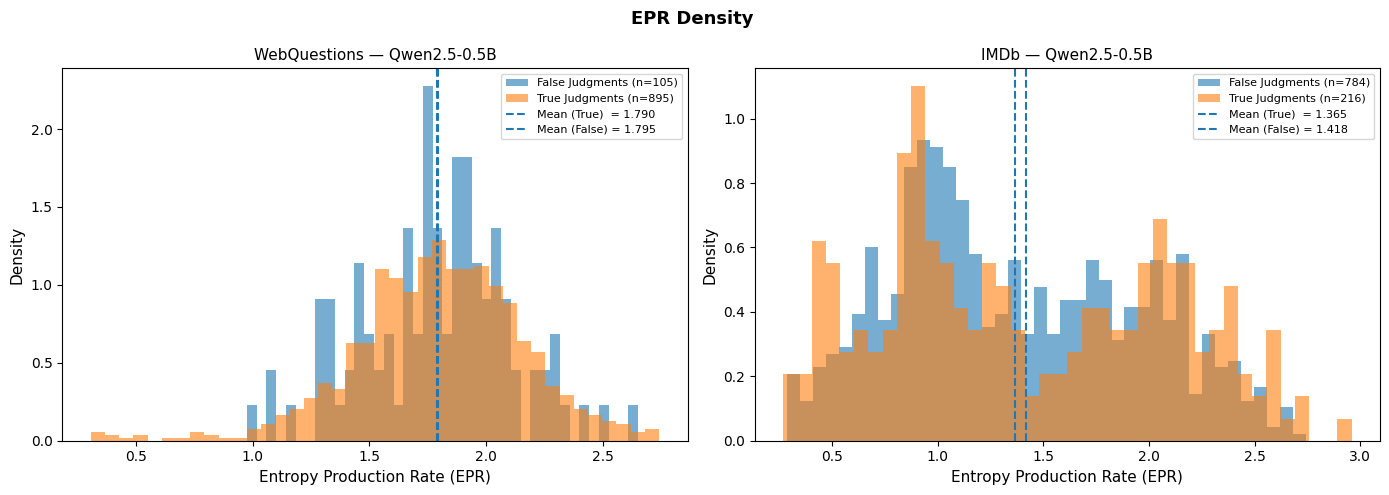

In [25]:
#  Figure  : Distribution EPR
def plot_epr_distribution(summary: dict, ax):
    df = summary["results_df"]
    epr_ok  = df.loc[df["correct"],  "epr"]
    epr_ko  = df.loc[~df["correct"], "epr"]

    # Histogrammes (sans couleur imposée)
    ax.hist(epr_ok, bins=40, alpha=0.6, density=True,
            label=f"False Judgments (n={len(epr_ok)})")
    ax.hist(epr_ko, bins=40, alpha=0.6, density=True,
            label=f"True Judgments (n={len(epr_ko)})")

    # Moyennes avec les mêmes couleurs implicites (récupérées automatiquement)
    if len(epr_ok) > 0:
        ax.axvline(epr_ok.mean(), linestyle="--", linewidth=1.5,
                   label=f"Mean (True)  = {epr_ok.mean():.3f}")
    if len(epr_ko) > 0:
        ax.axvline(epr_ko.mean(), linestyle="--", linewidth=1.5,
                   label=f"Mean (False) = {epr_ko.mean():.3f}")

    ax.set_xlabel("Entropy Production Rate (EPR)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"{summary['dataset']} — {summary['model']}", fontsize=11)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EPR Density ",
             fontsize=13, fontweight="bold")

plot_epr_distribution(summary_wq,   axes[0])
plot_epr_distribution(summary_imdb, axes[1])

plt.tight_layout()
plt.savefig("epr_distribution.png", dpi=150, bbox_inches="tight")
plt.show()